# Streamlined: IFU Spectral Extraction and ppxf Velocity Dispersion Fitting

This is a clean, streamlined version of the full exploratory notebook (`01_IFU_spectra_extraction_and_ppxf.ipynb`).
It performs the same analysis with no redundant steps:

1. Load the KCWI IFU data cube (once)
2. Extract integrated deflector and noise spectra
3. Fit the integrated spectrum with veldis (ppxf wrapper)
4. Fit per-spaxel velocity dispersion with ppxf
5. Power-bin spaxels by S/N and fit binned spectra

**Target:** AGEL0206 deflector galaxy, z = 0.675  
**Instrument:** Keck/KCWI medium slicer, R~4000

## 1. Imports and data loading

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

from veldis.veldis import Veldis

from time import perf_counter as clock
from importlib import resources
from urllib import request
from ppxf.ppxf import ppxf
import ppxf.ppxf_util as util
import ppxf.sps_util as lib
from tqdm import tqdm

# Plotting defaults
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('font', family='serif', size=14)
plt.rc('axes', linewidth=1.5, labelsize=16)
plt.rc('xtick', labelsize=14, direction='in')
plt.rc('ytick', labelsize=14, direction='in')


### Load the KCWI IFU data cube

The cube has axes `[wavelength, y_spatial, x_spatial]`. We build the wavelength
array from the FITS header WCS keywords.

In [12]:
# Load the IFU cube (only done once in this notebook)
ifu_file = '../Nov17_2025_DESJ0206_RL_combined_icubes_wcs.fits'

with fits.open(ifu_file) as hdul:
    hdr = hdul[0].header
    cube = np.asarray(hdul[0].data, dtype=float)

# Build wavelength array (Angstroms) from header WCS
crval = hdr['CRVAL3']
cdelt = hdr['CD3_3']
npix  = hdr['NAXIS3']
crpix = hdr.get('CRPIX3', 1.0)
pix   = np.arange(npix)
lam   = crval + cdelt * (pix + 1 - crpix)

print(f"Cube shape: {cube.shape}  (wavelength, y, x)")
print(f"Wavelength range: {lam[0]:.1f} - {lam[-1]:.1f} Angstroms")

Cube shape: (3317, 100, 100)  (wavelength, y, x)
Wavelength range: 5625.0 - 8941.0 Angstroms


## 2. Visualize the IFU field and extract spectra

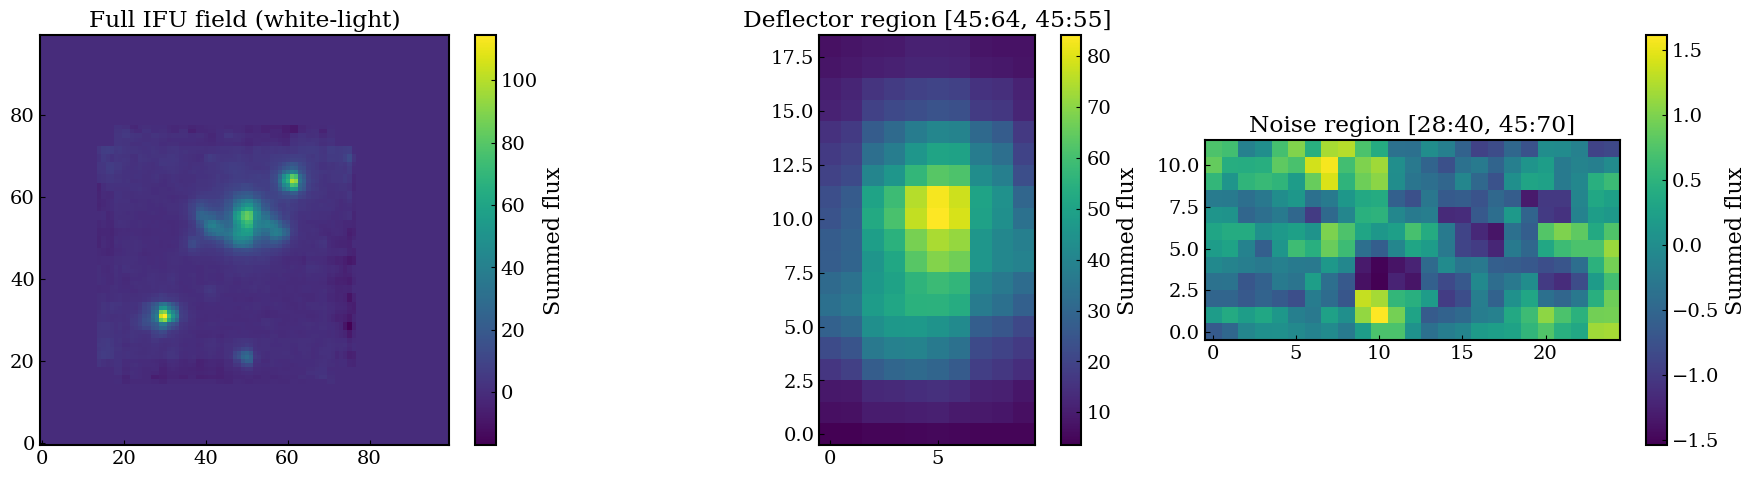

In [13]:
# White-light (wavelength-summed) image of the full IFU field
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Full field
im0 = axes[0].imshow(np.sum(cube, axis=0), origin='lower', cmap='viridis')
axes[0].set_title('Full IFU field (white-light)')
plt.colorbar(im0, ax=axes[0], label='Summed flux')

# Deflector region: spaxels [45:64, 45:55] = 19 x 10 spatial pixels
im1 = axes[1].imshow(np.sum(cube[:, 45:64, 45:55], axis=0), origin='lower', cmap='viridis')
axes[1].set_title('Deflector region [45:64, 45:55]')
plt.colorbar(im1, ax=axes[1], label='Summed flux')

# Noise/sky region: spaxels [28:40, 45:70] = 12 x 25 spatial pixels
im2 = axes[2].imshow(np.sum(cube[:, 28:40, 45:70], axis=0), origin='lower', cmap='viridis')
axes[2].set_title('Noise region [28:40, 45:70]')
plt.colorbar(im2, ax=axes[2], label='Summed flux')

plt.tight_layout()
plt.show()

### Extract integrated 1D spectra

Average across spaxels to get a single deflector spectrum and a noise estimate.
Convert vacuum wavelengths to air wavelengths using the standard IAU formula.

In [14]:
# Spatially-averaged spectra
# Deflector region: 19x10 spaxels; Noise/sky region: 12x25 spaxels
full_deflector = np.average(cube[:, 45:64, 45:55], axis=(1, 2))
noise_spectrum = np.average(cube[:, 28:40, 45:70], axis=(1, 2))

# Vacuum-to-air wavelength conversion (IAU standard)
def vac_to_air(lam_vac):
    s = 1e4 / lam_vac
    n = 1 + 0.0000834254 + 0.02406147 / (130 - s**2) + 0.00015998 / (38.9 - s**2)
    return lam_vac / n

lam_air = vac_to_air(lam)

# Spectral line rest wavelengths for visual identification
rest_lines = {
    'CaK': 3933.66, 'CaH': 3968.47, 'Gband': 4304.40,
    'MgI': 5175.27, 'FeI': 5270.40
}

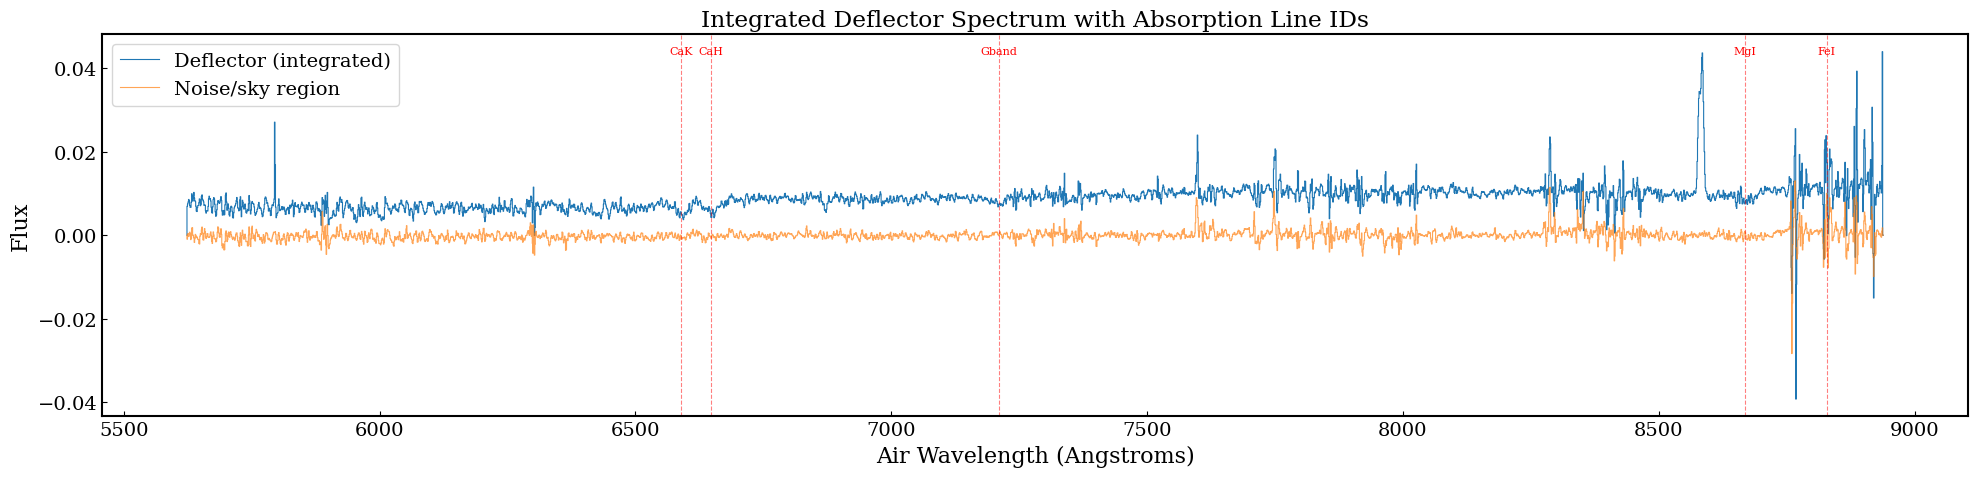

In [15]:
# Plot the extracted spectra with line identifications
z = 0.675  # Deflector redshift

fig, ax = plt.subplots(figsize=(20, 5))
ax.step(lam_air, full_deflector, lw=0.8, label='Deflector (integrated)')
ax.step(lam_air, noise_spectrum, lw=0.8, alpha=0.7, label='Noise/sky region')

for name, rest_wl in rest_lines.items():
    obs_wl = rest_wl * (1 + z)
    ax.axvline(obs_wl, color='red', ls='--', alpha=0.5, lw=0.8)
    ax.text(obs_wl, ax.get_ylim()[1] * 0.9, name, fontsize=8, ha='center', color='red')

ax.set_xlabel('Air Wavelength (Angstroms)')
ax.set_ylabel('Flux')
ax.set_title('Integrated Deflector Spectrum with Absorption Line IDs')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Fit integrated spectrum with ppxf

Fit the integrated deflector spectrum using ppxf directly with stellar population
synthesis (SPS) templates. We sweep over additive polynomial degrees 0-30 to assess
the stability of the velocity dispersion measurement, and support switching between
FSPS, EMILES, and XSL template libraries.

Key steps:
1. Rebin to logarithmic wavelength spacing (required by ppxf)
2. Normalize and convert vacuum to air wavelengths
3. Load SPS templates at the correct resolution
4. Run ppxf at each polynomial degree
5. Inspect velocity dispersion, mean velocity, chi2, and residuals as a function of degree

### 3a. Prepare the spectrum for ppxf

In [16]:
# Extract integrated deflector spectrum and noise
# Use std of the noise region as the noise estimate (more robust than mean)
flux_int = np.average(cube[:, 45:64, 45:55], axis=(1, 2))
noise_int = np.std(cube[:, 28:40, 45:70], axis=(1, 2))

# Rebuild wavelength array and trim to fitting range
lam_int = crval + cdelt * (pix + 1 - crpix)

# Trim to wavelength range with good signal
mask_wl = (lam_int >= 6500.0) & (lam_int <= 7500.0)
lam_int = lam_int[mask_wl]
flux_int = flux_int[mask_wl]
noise_int = noise_int[mask_wl]

# Refined deflector redshift
z = 0.67511

# Rebin to logarithmic wavelength spacing (required by ppxf for velocity-space convolution)
log_lam = np.log(lam_int)
d_log_lam = (log_lam[-1] - log_lam[0]) / (len(lam_int) - 1)
log_lam_new = np.arange(log_lam[0], log_lam[-1] + d_log_lam, d_log_lam)
flux_int = np.interp(log_lam_new, log_lam, flux_int)
noise_int = np.interp(log_lam_new, log_lam, noise_int)
lam_int = np.exp(log_lam_new)

# Apply final wavelength mask after rebinning
mask_fit = (lam_int >= 6000.0) & (lam_int <= 7500.0)
lam_int = lam_int[mask_fit]
flux_int = flux_int[mask_fit]
noise_int = noise_int[mask_fit]

print(f"Spectrum shape after prep: {lam_int.shape}")
print(f"Wavelength range: {lam_int[0]:.1f} - {lam_int[-1]:.1f} Angstroms")

Spectrum shape after prep: (1001,)
Wavelength range: 6500.0 - 7500.0 Angstroms


### 3b. Set up ppxf: templates and resolution

In [17]:
# Normalize spectrum
galaxy = flux_int / np.median(flux_int)

# Convert vacuum to air wavelengths
lam_gal = np.copy(lam_int)
lam_gal *= np.median(util.vac_to_air(lam_gal) / lam_gal)

redshift_0 = z

# Velocity scale in km/s per pixel (eq.8 of Cappellari 2017)
c_kms = 299792.458
d_ln_lam_gal = (np.log(lam_gal)[-1] - np.log(lam_gal)[0]) / (np.log(lam_gal).size - 1)
velscale = c_kms * d_ln_lam_gal

# --- Choose SPS template library ---
# Uncomment the one you want to use:
sps_name = 'fsps'
# sps_name = 'emiles'
# sps_name = 'xsl'

ppxf_dir = resources.files('ppxf')
basename = f"spectra_{sps_name}_9.0.npz"
filename = ppxf_dir / 'sps_models' / basename
if not filename.is_file():
    url = "https://raw.githubusercontent.com/micappe/ppxf_data/main/" + basename
    request.urlretrieve(url, filename)

# Instrumental resolution from FITS header
dlam_gal = np.gradient(lam_gal)
wdisp = hdr['DISPSCAL']                         # Instrumental dispersion in pixel units
fwhm_gal = 2.355 * wdisp * dlam_gal             # Resolution FWHM in Angstroms

# Convert to rest frame for template matching
lam_gal_rest = lam_gal / (1 + redshift_0)
fwhm_gal_rest = fwhm_gal / (1 + redshift_0)

# Load SPS templates
lam_range_temp = [3500, 5000]
fwhm_gal_dict = {"lam": lam_gal_rest, "fwhm": fwhm_gal_rest}

sps = lib.sps_lib(filename, velscale, fwhm_gal_dict, lam_range=lam_range_temp)
goodpixels = util.determine_goodpixels(np.log(lam_gal_rest), lam_range_temp)

print(f"Templates: {sps_name} ({len(sps.templates.T)} templates)")
print(f"Galaxy pixels: {len(galaxy)}, Good pixels: {len(goodpixels)}")

Templates: fsps (9 templates)
Galaxy pixels: 1001, Good pixels: 927


### 3c. Run ppxf across polynomial degrees 0-30

In [18]:
# Sweep over additive polynomial degrees to test stability of velocity dispersion
c_kms = 299792.458
vel = 0                  # Starting guess (spectrum is de-redshifted)
start = [vel, 300.]      # [V, sigma] starting guess in km/s
t = clock()

degrees = np.arange(0, 30)

# Storage containers
vel_dis = np.zeros(len(degrees))
error_vdis = np.zeros(len(degrees))
mean_vel = np.zeros(len(degrees))
error_vel = np.zeros(len(degrees))
fit_chi2 = np.zeros(len(degrees))
best_fit = []
residuals_avg = np.zeros(len(degrees))

for c, i in enumerate(degrees):
    pp = ppxf(sps.templates, galaxy, np.sqrt(noise_int**2), velscale, start,
              goodpixels=goodpixels, plot=False, moments=2, trig=False,
              degree=i, lam=lam_gal_rest, lam_temp=sps.lam_temp, mdegree=0)
    vel_dis[c] = pp.sol[1]
    error_vdis[c] = pp.error[1] * np.sqrt(pp.chi2)
    mean_vel[c] = pp.sol[0]
    error_vel[c] = pp.error[0] * np.sqrt(pp.chi2)
    fit_chi2[c] = pp.chi2
    best_fit.append(pp.bestfit)
    residuals_avg[c] = np.median(np.abs(pp.bestfit - galaxy))

print(f'Elapsed time in pPXF: {clock() - t:.2f} s')

# Print best-fitting redshift from the last fit
errors = pp.error * np.sqrt(pp.chi2)
redshift_fit = (1 + redshift_0) * np.exp(pp.sol[0] / c_kms) - 1
redshift_err = (1 + redshift_fit) * errors[0] / c_kms
print(f"Best-fitting redshift z = {redshift_fit:.5f} +/- {redshift_err:.5f}")
print(f"Velocity dispersion (degree=16): {vel_dis[16]:.1f} +/- {error_vdis[16]:.1f} km/s")

 Best Fit:       Vel     sigma
 comp.  0:        -2       272
chi2/DOF: 567.7; DOF: 925; degree = 0; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
 Best Fit:       Vel     sigma
 comp.  0:        -2       273
chi2/DOF: 567.6; DOF: 925; degree = 1; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
 Best Fit:       Vel     sigma
 comp.  0:        -5       265
chi2/DOF: 564.1; DOF: 925; degree = 2; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:        -4       269
chi2/DOF: 563.9; DOF: 925; degree = 3; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:        -3       266
chi2/DOF: 563.6; DOF: 925; deg

### 3d. Diagnostic plots: stability vs polynomial degree

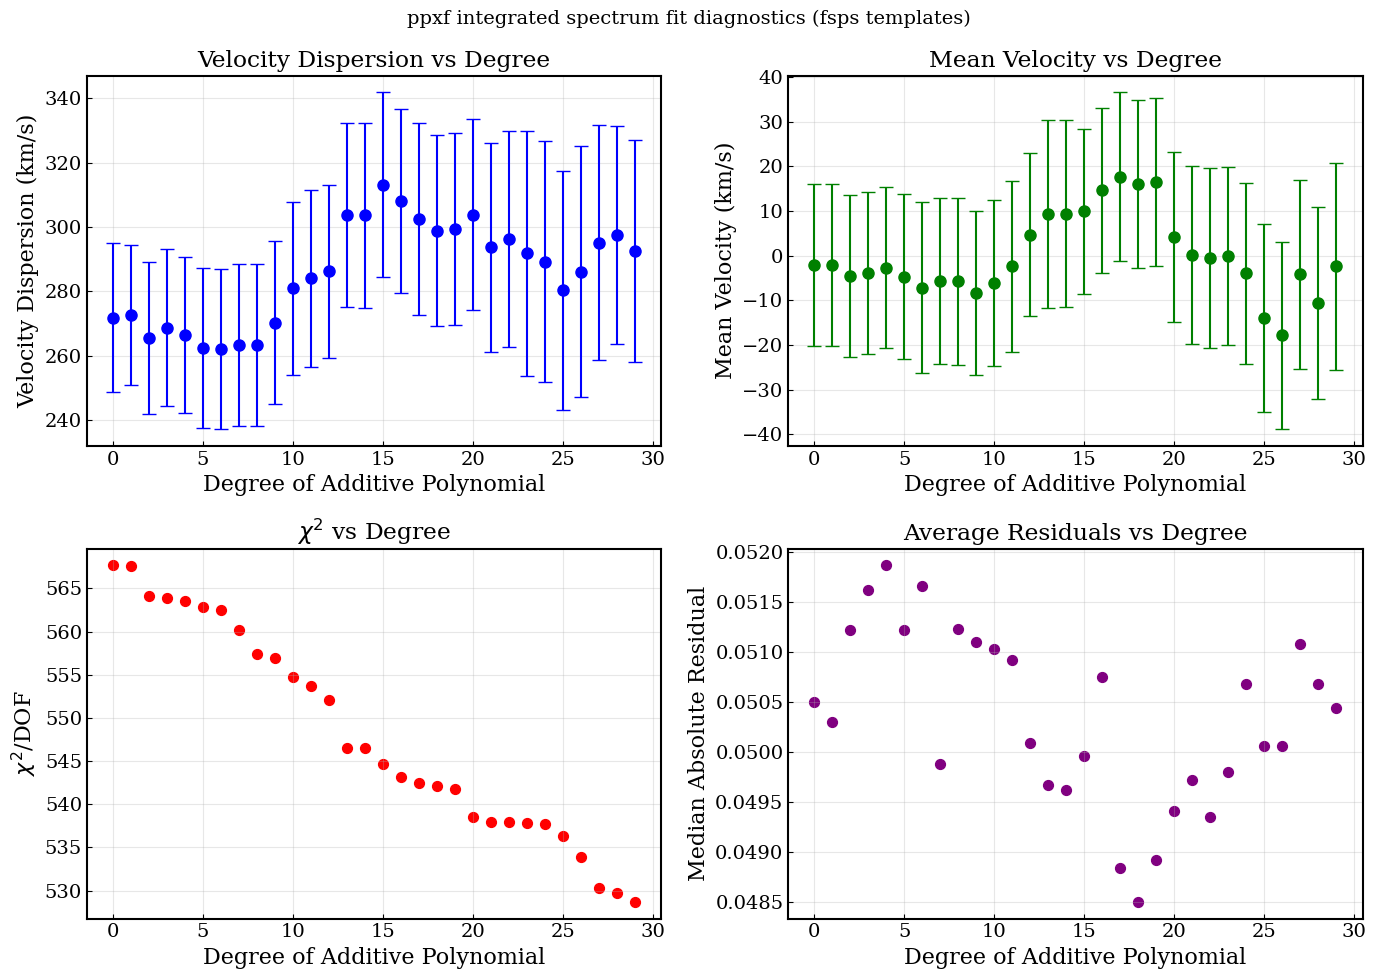

In [19]:
# 2x2 diagnostic plot: how velocity dispersion, velocity, chi2, and residuals
# vary as a function of additive polynomial degree
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Velocity Dispersion vs Degree
axes[0, 0].errorbar(degrees, vel_dis, yerr=error_vdis, c='b', fmt='o', capsize=5, markersize=8)
axes[0, 0].set_xlabel('Degree of Additive Polynomial')
axes[0, 0].set_ylabel('Velocity Dispersion (km/s)')
axes[0, 0].set_title('Velocity Dispersion vs Degree')
axes[0, 0].grid(alpha=0.3)

# Mean Velocity vs Degree
axes[0, 1].errorbar(degrees, mean_vel, yerr=error_vel, c='g', fmt='o', capsize=5, markersize=8)
axes[0, 1].set_xlabel('Degree of Additive Polynomial')
axes[0, 1].set_ylabel('Mean Velocity (km/s)')
axes[0, 1].set_title('Mean Velocity vs Degree')
axes[0, 1].grid(alpha=0.3)

# Chi2 vs Degree
axes[1, 0].scatter(degrees, fit_chi2, c='r', s=50)
axes[1, 0].set_xlabel('Degree of Additive Polynomial')
axes[1, 0].set_ylabel(r'$\chi^2$/DOF')
axes[1, 0].set_title(r'$\chi^2$ vs Degree')
axes[1, 0].grid(alpha=0.3)

# Median Absolute Residuals vs Degree
residuals_recomputed = [np.median(np.abs(best_fit[i] - galaxy)) for i in range(len(degrees))]
axes[1, 1].scatter(degrees, residuals_recomputed, c='purple', s=50)
axes[1, 1].set_xlabel('Degree of Additive Polynomial')
axes[1, 1].set_ylabel('Median Absolute Residual')
axes[1, 1].set_title('Average Residuals vs Degree')
axes[1, 1].grid(alpha=0.3)

plt.suptitle(f'ppxf integrated spectrum fit diagnostics ({sps_name} templates)', fontsize=14)
plt.tight_layout()
plt.show()

### 3e. Inspect best-fit spectrum at a chosen degree

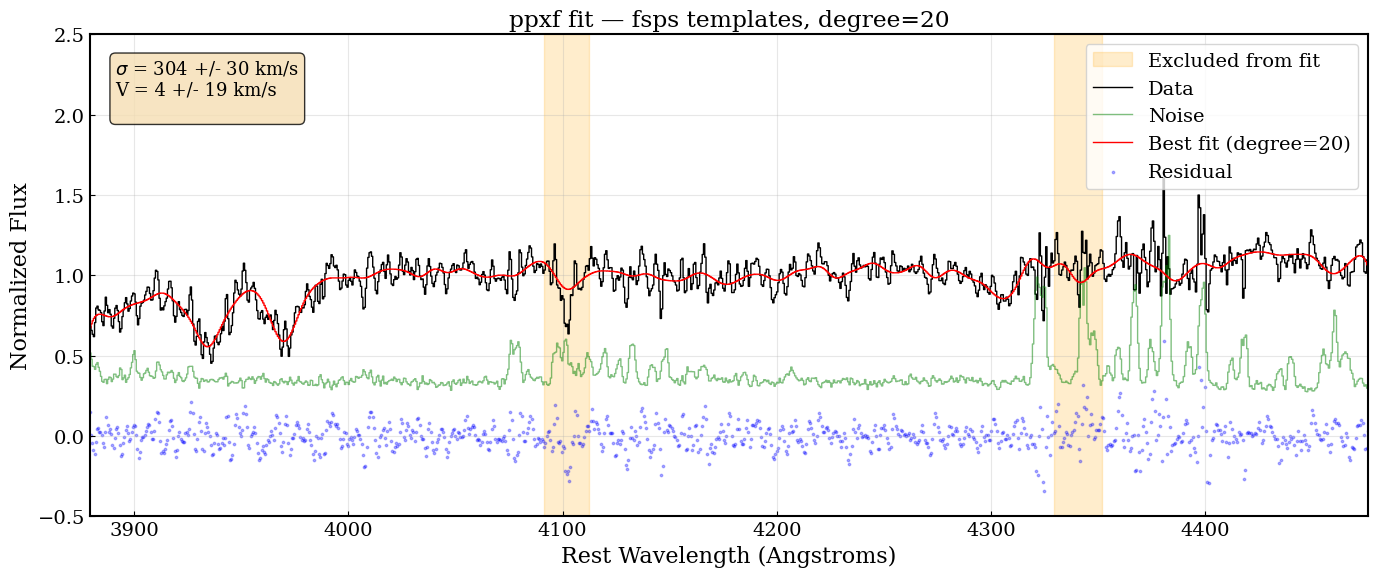

Total pixels: 1001, Good pixels: 927, Excluded: 74 (7.4%)


In [26]:
# Plot the best-fit spectrum for a chosen polynomial degree,
# highlighting the regions excluded from the fit (masked by goodpixels)
deg_inspect = 20  # Change this to inspect different degrees
residuals = [galaxy - best_fit[i] for i in range(len(degrees))]

fig, ax = plt.subplots(figsize=(14, 6))

# Shade excluded (masked) regions
# goodpixels contains the indices of pixels INCLUDED in the fit;
# everything else was excluded (e.g. emission lines, sky features)
all_pixels = np.arange(len(galaxy))
bad_pixels = np.setdiff1d(all_pixels, goodpixels)

# Find contiguous runs of excluded pixels to draw shaded regions
if len(bad_pixels) > 0:
    splits = np.where(np.diff(bad_pixels) > 1)[0] + 1
    bad_runs = np.split(bad_pixels, splits)
    for run in bad_runs:
        ax.axvspan(lam_gal_rest[run[0]], lam_gal_rest[run[-1]],
                   color='orange', alpha=0.2, label='_nolegend_')
    # Add one labeled patch for the legend
    ax.axvspan(0, 0, color='orange', alpha=0.2, label='Excluded from fit')

ax.step(lam_gal_rest, galaxy, c='k', lw=1, label='Data')
ax.step(lam_gal_rest, np.sqrt(noise_int**2) / np.median(flux_int), c='g', lw=1, alpha=0.5, label='Noise')
ax.step(lam_gal_rest, best_fit[deg_inspect], c='r', lw=1, label=f'Best fit (degree={deg_inspect})')
ax.scatter(lam_gal_rest, residuals[deg_inspect], c='b', s=3, alpha=0.3, label='Residual')
ax.text(0.02, 0.95,
        f'$\sigma$ = {vel_dis[deg_inspect]:.0f} +/- {error_vdis[deg_inspect]:.0f} km/s\n'
        f'V = {mean_vel[deg_inspect]:.0f} +/- {error_vel[deg_inspect]:.0f} km/s\n',
        #f'$\chi^2$/DOF = {fit_chi2[deg_inspect]:.2f}',
        transform=ax.transAxes, fontsize=13, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
ax.set_xlabel('Rest Wavelength (Angstroms)')
ax.set_ylabel('Normalized Flux')
ax.set_title(f'ppxf fit — {sps_name} templates, degree={deg_inspect}')
ax.set_ylim(-0.5, 2.5)
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
ax.set_xlim(lam_gal_rest[0], lam_gal_rest[-1])
plt.tight_layout()
plt.show()

print(f"Total pixels: {len(galaxy)}, Good pixels: {len(goodpixels)}, "
      f"Excluded: {len(bad_pixels)} ({100*len(bad_pixels)/len(galaxy):.1f}%)")

## 4. Per-spaxel ppxf fitting

Fit each of the 190 individual spaxels (19 x 10 grid) using raw ppxf with FSPS
stellar templates. We iterate over multiple additive polynomial degrees [15, 17, 20]
and average the results for robustness.

In [ ]:
def ppxf_per_spaxel(degrees,lam,flux,noise, z):
    # Rebin to logarithmic wavelength spacing
    log_lam = np.log(lam)
    d_log_lam = (log_lam[-1] - log_lam[0]) / (len(lam) - 1)
    log_lam_new = np.arange(log_lam[0], log_lam[-1] + d_log_lam, d_log_lam)
    flux = np.interp(log_lam_new, log_lam, flux)
    noise = np.interp(log_lam_new, log_lam, noise)
    lam = np.exp(log_lam_new)

    # Mask wavelength range for pPXF fitting
    mask = (lam >= 6000.0) & (lam <= 7500.0)
    lam, flux, noise = lam[mask], flux[mask], noise[mask],
    print(np.shape(lam), np.shape(flux), np.shape(noise))


    galaxy = flux/np.median(flux)     # Normalize spectrum to avoid numerical issues
    lam_gal = np.copy(lam)                # Wavelength in Angstroms (log sampled)
    lam_gal *= np.median(util.vac_to_air(lam_gal)/lam_gal)

    redshift_0 = z

    c = 299792.458  # speed of light in km/s
    d_ln_lam_gal = (np.log(lam_gal)[-1] - np.log(lam_gal)[0])/(np.log(lam_gal).size - 1)  # Use full lam range for accuracy
    velscale = c*d_ln_lam_gal                   # Velocity scale in km/s per pixel (eq.8 of Cappellari 2017)


    ppxf_dir = resources.files('ppxf')

    sps_name = 'fsps'
    # sps_name = 'galaxev'
    # sps_name = 'emiles'
    #sps_name = 'xsl'

    basename = f"spectra_{sps_name}_9.0.npz"
    filename = ppxf_dir / 'sps_models' / basename
    if not filename.is_file():
        url = "https://raw.githubusercontent.com/micappe/ppxf_data/main/" + basename
        request.urlretrieve(url, filename)



    dlam_gal = np.gradient(lam_gal)             # Size of every pixel in Angstroms
    wdisp = hdr['DISPSCAL']                          # Instrumental dispersion of every pixel, in pixels units
    fwhm_gal = 2.355*wdisp*dlam_gal             # Resolution FWHM of every pixel, in Angstroms

    lam_gal = lam_gal/(1 + redshift_0)      # Compute approximate restframe wavelength
    fwhm_gal = fwhm_gal/(1 + redshift_0)    # Adjust resolution in Angstroms


    lam_range_temp = [3500, 5000]
    fwhm_gal = {"lam": lam_gal, "fwhm": fwhm_gal}


    sps = lib.sps_lib(filename, velscale, fwhm_gal, lam_range=lam_range_temp)
    goodpixels = util.determine_goodpixels(np.log(lam_gal), lam_range_temp)
    # pPXF fitting
    # Here the actual fit starts. The best fit is plotted on the screen. Gas emission lines are excluded from the pPXF fit using the goodpixels keyword.

    c = 299792.458          # km/s
    vel = 0                 # Spectrum is de-redshifted --> starting guess is zero
    start = [vel, 300.]     # (km/s), starting guess for [V, sigma]
    t = clock()

    """Setup the containers to store velocity dispersion and error 
        values """
    vel_dis = np.zeros(len(degrees)) 
    error_vdis = np.zeros(len(degrees  ))
    best_fit = []
    temp_weight = []
    add_deg_weight = []
    mul_deg_weight = []
    mean_vel = np.zeros(len(degrees))
    error_vel = np.zeros(len(degrees))
    fit_chi2 = np.zeros(len(degrees))
    """good pixels are the pixels which have been used in the fit"""
    good_pixels = []    
    residuals_avg = np.zeros(len(degrees))

    for c, i in enumerate(degrees):
        pp = ppxf(sps.templates, galaxy, np.sqrt((noise)**2), velscale, start,
                goodpixels=goodpixels, plot=False, moments=2, trig=False,
                degree=i, lam=lam_gal, lam_temp=sps.lam_temp, mdegree= 0)
        vel_dis[c] = pp.sol[1]
        error_vdis[c] = pp.error[1]*np.sqrt(pp.chi2)
        best_fit.append(pp.bestfit)
        mean_vel[c] = pp.sol[0]
        error_vel[c] = pp.error[0]*np.sqrt(pp.chi2)
        fit_chi2[c] = pp.chi2
        best_fit.append(pp.bestfit)
        good_pixels.append(pp.goodpixels)
        temp_weight.append(pp.weights)
        add_deg_weight.append(pp.polyweights)
        mul_deg_weight.append(pp.mpolyweights)
        residuals_avg[c] = np.median(np.abs(pp.bestfit - galaxy))
        # plt.show()
        # plt.close()

    print('Elapsed time in pPXF: %.2f s' % (clock() - t))


    errors = pp.error*np.sqrt(pp.chi2)  # Assume the fit is good chi2/DOF=1
    redshift_fit = (1 + redshift_0)*np.exp(pp.sol[0]/c) - 1     # eq. (5c) C23
    redshift_err = (1 + redshift_fit)*errors[0]/c               # eq. (5d) C23

    # print("Formal errors:")
    # print("     dV    dsigma   dh3      dh4")
    # print("".join("%8.2g" % f for f in errors))
    # prec = int(1 - np.floor(np.log10(redshift_err)))  # two digits of uncertainty
    # print(f"Best-fitting redshift z = {redshift_fit:#.{prec}f} "
    #     f"+/- {redshift_err:#.{prec}f}")

    # pp.plot()
    # plt.title(f"pPXF fit with {sps_name} SPS templates")

    out_dict = {
        'degrees'  : degrees,
        'vel_dis': vel_dis,
        'error_vdis': error_vdis,
        'mean_vel': mean_vel,
        'error_vel': error_vel,
        'fit_chi2': fit_chi2,   
        'best_fit': best_fit,
        'good_pixels': good_pixels,
        'temp_weight': temp_weight,
        'add_deg_weight': add_deg_weight,
        'mul_deg_weight': mul_deg_weight,
        'residuals_avg': residuals_avg,
        'lam_gal': lam_gal,
        'galaxy': pp.galaxy,
        'noise': pp.noise
    }
    return out_dict


In [ ]:
# Extract per-spaxel flux arrays from the deflector region
fluxes_per_spaxel = cube[:, 45:64, 45:55].reshape(cube.shape[0], -1).T  # (190, n_wavelength)
noise_for_ppxf = np.average(cube[:, 28:40, 45:70], axis=(1, 2))

# Fit all 190 spaxels with ppxf at multiple polynomial degrees
degrees = np.array([15, 17, 20])
z_ppxf = 0.678

fit_results_per_spaxel = []
for i in tqdm(range(len(fluxes_per_spaxel)), desc="Per-spaxel ppxf"):
    result = ppxf_per_spaxel(degrees, lam, fluxes_per_spaxel[i], noise_for_ppxf, z_ppxf)
    fit_results_per_spaxel.append(result)

In [ ]:
# Extract velocity dispersion for each spaxel (average across degrees as robust estimate)
n_y, n_x = 19, 10  # shape of cube[:,45:64,45:55]

vel_dis_map = np.zeros(len(fit_results_per_spaxel))
vel_dis_err_map = np.zeros(len(fit_results_per_spaxel))

for idx, result in enumerate(fit_results_per_spaxel):
    vel_dis_map[idx] = np.mean(result['vel_dis'])
    vel_dis_err_map[idx] = np.mean(result['error_vdis'])

# Reshape to 2D spatial grid
vel_dis_2d = vel_dis_map.reshape(n_y, n_x)
vel_dis_err_2d = vel_dis_err_map.reshape(n_y, n_x)

# Collapsed image of the deflector for reference
deflector_image = np.sum(cube[:,45:64,45:55], axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# White-light image
im0 = axes[0].imshow(deflector_image, origin='lower', cmap='viridis')
axes[0].set_title('White-light Image (Deflector)')
axes[0].set_xlabel('X spaxel')
axes[0].set_ylabel('Y spaxel')
plt.colorbar(im0, ax=axes[0], label='Summed Flux')

# Velocity dispersion heatmap
im1 = axes[1].imshow(vel_dis_2d, origin='lower', cmap='RdYlBu_r',
                     vmin=np.nanpercentile(vel_dis_2d, 5),
                     vmax=np.nanpercentile(vel_dis_2d, 95))
axes[1].set_title(f'Velocity Dispersion Map (mean over degrees={degrees})')
axes[1].set_xlabel('X spaxel')
axes[1].set_ylabel('Y spaxel')
plt.colorbar(im1, ax=axes[1], label='$\sigma$ (km/s)')

# Velocity dispersion error heatmap
im2 = axes[2].imshow(vel_dis_err_2d, origin='lower', cmap='hot',
                     vmin=np.nanpercentile(vel_dis_err_2d, 5),
                     vmax=np.nanpercentile(vel_dis_err_2d, 95))
axes[2].set_title(f'Velocity Dispersion Error Map (mean over degrees={degrees})')
axes[2].set_xlabel('X spaxel')
axes[2].set_ylabel('Y spaxel')
plt.colorbar(im2, ax=axes[2], label='$\delta\sigma$ (km/s)')

plt.tight_layout()
plt.show()


In [ ]:
# Extract velocity dispersion for each spaxel (average across degrees as robust estimate)
n_y, n_x = 19, 10  # shape of cube[:,45:64,45:55]

vel_dis_map = np.zeros(len(fit_results_per_spaxel))
vel_dis_err_map = np.zeros(len(fit_results_per_spaxel))

for idx, result in enumerate(fit_results_per_spaxel):
    vel_dis_map[idx] = np.mean(result['mean_vel'])
    vel_dis_err_map[idx] = np.mean(result['error_vel'])

# Reshape to 2D spatial grid
vel_dis_2d = vel_dis_map.reshape(n_y, n_x)
vel_dis_err_2d = vel_dis_err_map.reshape(n_y, n_x)

# Collapsed image of the deflector for reference
deflector_image = np.sum(cube[:,45:64,45:55], axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# White-light image
im0 = axes[0].imshow(deflector_image, origin='lower', cmap='viridis')
axes[0].set_title('White-light Image (Deflector)')
axes[0].set_xlabel('X spaxel')
axes[0].set_ylabel('Y spaxel')
plt.colorbar(im0, ax=axes[0], label='Summed Flux')

# Velocity dispersion heatmap
im1 = axes[1].imshow(vel_dis_2d, origin='lower', cmap='RdYlBu_r',
                     vmin=np.nanpercentile(vel_dis_2d, 5),
                     vmax=np.nanpercentile(vel_dis_2d, 95))
axes[1].set_title(f'Velocity Dispersion Map (mean over degrees={degrees})')
axes[1].set_xlabel('X spaxel')
axes[1].set_ylabel('Y spaxel')
plt.colorbar(im1, ax=axes[1], label='$V$ (km/s)')

# Velocity dispersion error heatmap
im2 = axes[2].imshow(vel_dis_err_2d, origin='lower', cmap='hot',
                     vmin=np.nanpercentile(vel_dis_err_2d, 5),
                     vmax=np.nanpercentile(vel_dis_err_2d, 95))
axes[2].set_title(f'Velocity Dispersion Error Map (mean over degrees={degrees})')
axes[2].set_xlabel('X spaxel')
axes[2].set_ylabel('Y spaxel')
plt.colorbar(im2, ax=axes[2], label='$\delta V$ (km/s)')

plt.tight_layout()
plt.show()


## 5. Power-binning and binned ppxf fitting

Individual spaxels can have low S/N. We use [PowerBin](https://github.com/kvgc153/powerbin)
to adaptively bin spaxels to a target S/N, then re-run ppxf on each bin.
This provides spatially-resolved kinematics with better precision.

### 5a. Compute the S/N map and run PowerBin

In [ ]:
from powerbin import PowerBin

# Re-load data for power-binning with updated parameters
# Use a wider spatial region and updated noise estimate
z = 0.67511  # Refined redshift

# Reload wavelength array and trim to fitting range
lam_pb = crval + cdelt * (pix + 1 - crpix)
cube_pb = cube[:, 35:75, 30:70]  # Wider region around deflector

# Noise estimate from sky region (median std across wavelength channels)
noise_pb = np.median(np.std(cube[:, 28:40, 45:70], axis=(1, 2)))

# Wavelength mask for ppxf fitting
mask_pb = (lam_pb >= 6500.0) & (lam_pb <= 7500.0)
lam_pb = lam_pb[mask_pb]

# Compute the S/N map
data_collapsed = np.average(cube_pb, axis=0)  # White-light image
noise_map = np.ones_like(data_collapsed) * noise_pb
noise_std_map = np.std(cube_pb, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes[0].imshow(data_collapsed / noise_map, origin='lower', cmap='viridis')
axes[0].set_title('S/N Map (uniform noise)')
plt.colorbar(im0, ax=axes[0], label='S/N')
im1 = axes[1].imshow(data_collapsed / noise_std_map, origin='lower', cmap='viridis')
axes[1].set_title('S/N Map (per-pixel noise)')
plt.colorbar(im1, ax=axes[1], label='S/N')
plt.tight_layout()
plt.show()

In [ ]:
# Set up spatial coordinates for PowerBin
xp, yp = np.arange(cube_pb.shape[1]), np.arange(cube_pb.shape[2])
xx, yy = np.meshgrid(xp, yp)
xy = np.column_stack([xx.ravel(), yy.ravel()])

signal_flat = data_collapsed.ravel()
noise_flat = noise_map.ravel()

# Target S/N = 10 per bin
target_sn = 10

# Define capacity function for adaptive binning
def capacity_spec(index):
    sn = np.sum(signal_flat[index]) / np.sqrt(np.sum(noise_flat[index]**2))
    return sn**2

# Run PowerBin
pow_bins = PowerBin(xy, capacity_spec, target_capacity=target_sn**2)
pow_bins.plot(capacity_scale='sqrt', ylabel='S/N')
plt.show()

In [ ]:
# Visualize the bin assignments
powerbin_idxs = pow_bins.bin_num
powerbin_idx_map = np.reshape(powerbin_idxs, (data_collapsed.shape[0], data_collapsed.shape[1]))

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(powerbin_idx_map, origin='lower')

# Label each bin at its centroid
n_bins = len(pow_bins.npix)
for bin_id in range(n_bins):
    ys, xs = np.where(powerbin_idx_map == bin_id)
    if len(xs) > 0:
        ax.text(np.mean(xs), np.mean(ys), str(bin_id),
                ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax.set_title(f'PowerBin assignments ({n_bins} bins, target S/N={target_sn})')
plt.show()

### 5b. Extract binned spectra and run ppxf

In [ ]:
# Average spectra within each power-bin
fluxes_binned = np.zeros((cube_pb.shape[0], n_bins)).T
for i in range(n_bins):
    fluxes_binned[i] = np.average(cube_pb[:, powerbin_idx_map == i], axis=1)

# Trim to the wavelength mask
fluxes_binned = fluxes_binned[:, mask_pb]
noise_pb_val = np.std(cube[:, 28:40, 45:70], axis=(1, 2))[mask_pb]

print(f"Binned spectra shape: {fluxes_binned.shape}  ({n_bins} bins x {fluxes_binned.shape[1]} wavelength pixels)")

In [ ]:
# Run ppxf on each power-bin (degrees 10-24 for robustness)
degrees_pb = np.arange(10, 25, 1)

fit_results_powerbin = []
for i in tqdm(range(n_bins), desc="Power-bin ppxf"):
    result = ppxf_per_spaxel(degrees_pb, lam_pb, fluxes_binned[i], noise_pb_val, z)
    fit_results_powerbin.append(result)

### 5c. Visualize power-binned velocity dispersion and mean velocity

In [ ]:
# Map velocity dispersion back to spatial grid
vel_dis_map_pb = np.zeros(n_bins)
vel_dis_err_pb = np.zeros(n_bins)
mean_vel_map_pb = np.zeros(n_bins)
mean_vel_err_pb = np.zeros(n_bins)

for idx, result in enumerate(fit_results_powerbin):
    vel_dis_map_pb[idx] = np.mean(result['vel_dis'])
    vel_dis_err_pb[idx] = np.mean(result['error_vdis'])
    mean_vel_map_pb[idx] = np.mean(result['mean_vel'])
    mean_vel_err_pb[idx] = np.mean(result['error_vel'])

# Reconstruct 2D maps from bin assignments
vel_dis_2d_pb = np.zeros(powerbin_idx_map.shape)
mean_vel_2d_pb = np.zeros(powerbin_idx_map.shape)
for idx in range(n_bins):
    vel_dis_2d_pb[powerbin_idx_map == idx] = vel_dis_map_pb[idx]
    mean_vel_2d_pb[powerbin_idx_map == idx] = mean_vel_map_pb[idx]

deflector_image_pb = np.sum(cube_pb, axis=0)
delta = 10  # Zoom window around center

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im0 = axes[0].imshow(deflector_image_pb[20-delta:20+delta, 20-delta:20+delta],
                      origin='lower', cmap='viridis')
axes[0].set_title('White-light Image')
plt.colorbar(im0, ax=axes[0], label='Summed Flux')

im1 = axes[1].imshow(vel_dis_2d_pb[20-delta:20+delta, 20-delta:20+delta],
                      origin='lower', cmap='plasma', vmin=0, vmax=500)
axes[1].set_title('Velocity Dispersion (power-binned)')
axes[1].contour(deflector_image_pb[20-delta:20+delta, 20-delta:20+delta],
                levels=5, colors='white', alpha=0.5, linewidths=0.8)
plt.colorbar(im1, ax=axes[1], label=r'$\sigma$ (km/s)')

im2 = axes[2].imshow(mean_vel_2d_pb[20-delta:20+delta, 20-delta:20+delta],
                      origin='lower', cmap='RdYlBu_r', vmin=-100, vmax=100)
axes[2].set_title('Mean Velocity (power-binned)')
axes[2].contour(deflector_image_pb[20-delta:20+delta, 20-delta:20+delta],
                levels=5, colors='white', alpha=0.5, linewidths=0.8)
plt.colorbar(im2, ax=axes[2], label='V (km/s)')

plt.tight_layout()
plt.show()

In [ ]:
# Plot ppxf best-fit spectra for each power-bin (at degree=20)
deg_target = 20
degrees_list = list(np.arange(10, 25, 1))
deg_idx = degrees_list.index(deg_target)
best_fit_idx = deg_idx * 2  # best_fit appended twice per degree in ppxf_per_spaxel

ncols = 5
nrows = int(np.ceil(n_bins / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 3))
axes = axes.ravel()

for bin_id, result in enumerate(fit_results_powerbin):
    ax = axes[bin_id]
    lam_g = result['lam_gal']
    galaxy_spec = result['galaxy']
    noise_fit = result['noise']
    bf = result['best_fit'][best_fit_idx]

    ax.step(lam_g, galaxy_spec, c='k', lw=1, label='Data')
    ax.step(lam_g, noise_fit, c='g', lw=1, alpha=0.5, label='Noise')
    ax.step(lam_g, bf, c='r', lw=1, label='Best fit')
    ax.scatter(lam_g, galaxy_spec - bf, c='b', s=2, alpha=0.3, label='Residual')

    vd = result['vel_dis'][deg_idx]
    ev = result['error_vdis'][deg_idx]
    mv = result['mean_vel'][deg_idx]
    emv = result['error_vel'][deg_idx]
    ax.set_title(f'Bin {bin_id} | $\sigma$={vd:.0f}+/-{ev:.0f}, V={mv:.0f}+/-{emv:.0f} km/s', fontsize=9)
    ax.set_xlabel('Rest $\lambda$ (Ang)', fontsize=8)
    ax.set_ylabel('Norm. Flux', fontsize=8)
    ax.set_ylim(-0.5, 2.5)
    ax.grid(alpha=0.3)
    if bin_id == 0:
        ax.legend(fontsize=7)

for ax in axes[n_bins:]:
    ax.set_visible(False)

plt.suptitle(f'ppxf fits per power-bin (degree={deg_target})', fontsize=13)
plt.tight_layout()
plt.savefig(f'ppxf_fits_per_powerbin_deg{deg_target}.png', dpi=300, bbox_inches='tight')
plt.show()